## Concrate Project

Exploring concrete data from UCI and determining the best model for predicting concrete strength. 

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)        1030 

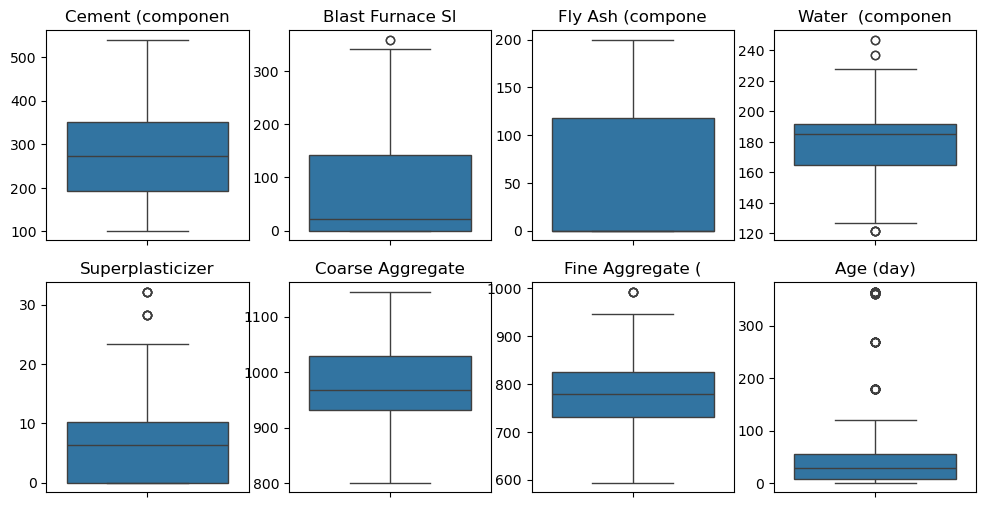

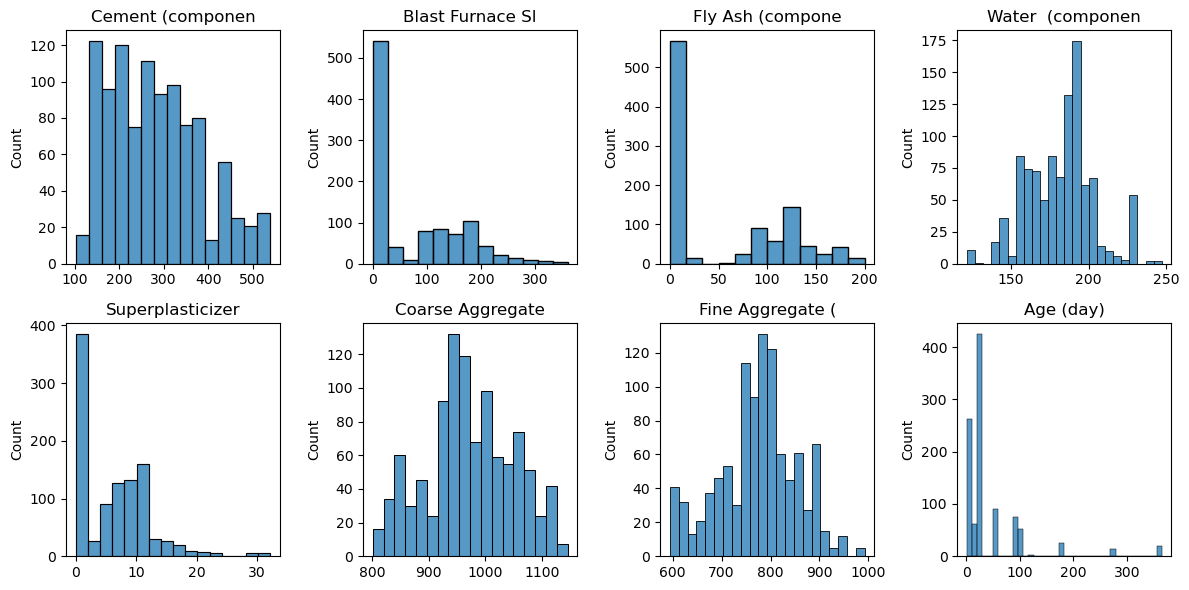

In [70]:
df_original = pd.read_csv(r"C:\Users\Russell\Concrete\Copy of Concrete_Data.csv")
df = df_original.copy()

print(df.info())

Cement_describe = df['Cement (component 1)(kg in a m^3 mixture)'].describe()
Blast_Furnace_describe = df['Blast Furnace Slag (component 2)(kg in a m^3 mixture)'].describe()
Fly_Ash_describe = df['Fly Ash (component 3)(kg in a m^3 mixture)'].describe()
Water_describe = df['Water  (component 4)(kg in a m^3 mixture)'].describe()
Superplasticizer_describe = df['Superplasticizer (component 5)(kg in a m^3 mixture)'].describe()
Corase_Aggregate_describe = df['Coarse Aggregate  (component 6)(kg in a m^3 mixture)'].describe()
Fine_Aggregate_describe = df['Fine Aggregate (component 7)(kg in a m^3 mixture)'].describe()
Age_describe = df['Age (day)'].describe() 

consolidate_describe = pd.DataFrame(
    data={
        'Cement': Cement_describe,
        'Blast Furance': Blast_Furnace_describe,
        'Fly Ash': Fly_Ash_describe,
        "Water": Water_describe,
        "Superplasticizer": Superplasticizer_describe,
        "Corase Aggregate": Corase_Aggregate_describe,
        "Fine Aggregate": Fine_Aggregate_describe,
        "Age": Age_describe 
    }
)

print(consolidate_describe)

fig, axes1 = plt.subplots(nrows=2, ncols=4, figsize=(12,6))
axes1 = axes1.flatten()
col_names = df.columns

for i in range(len(col_names)-1):
    sns.boxplot(data=df, y=col_names[i], ax=axes1[i])
    axes1[i].set_title(col_names[i][:16])
    axes1[i].set_ylabel("")

fig, axes2 = plt.subplots(nrows=2, ncols=4, figsize=(12,6))
axes2 = axes2.flatten()

for i in range(len(col_names)-1):
    sns.histplot(data=df, x=col_names[i], ax=axes2[i])
    axes2[i].set_xlabel("")
    axes2[i].set_title(col_names[i][:16])

plt.tight_layout()

In [99]:
print(df[f'{col_names[7]}'].value_counts())
print(df[f'{col_names[7]}'].value_counts().sort_index())

print(df[df[f'{col_names[7]}'] > 125])

Age (day)
28     425
3      134
7      126
56      91
14      62
90      54
100     52
180     26
91      22
365     14
270     13
360      6
120      3
1        2
Name: count, dtype: int64
Age (day)
1        2
3      134
7      126
14      62
28     425
56      91
90      54
91      22
100     52
120      3
180     26
270     13
360      6
365     14
Name: count, dtype: int64
     Cement (component 1)(kg in a m^3 mixture)  \
2                                        332.5   
3                                        332.5   
4                                        198.6   
6                                        380.0   
12                                       427.5   
17                                       342.0   
19                                       475.0   
20                                       427.5   
23                                       139.6   
24                                       380.0   
25                                       380.0   
26                  

## EDA

There are 8 interdependent Variables: Cement, Blast Furance, Fly Ash, Water, Superplasticizer, Corase Aggregate, Fine Aggregate, Age.

Our EDA process consists of preliminarily looking at the distribution of each variable as well as utilizing the boxplots to visaully inspect. 

# Cement 
Data is left skewed, but there doesnt appear to be signficant evidence of outliers

# BlastFurnace 
Very left skewed, with 471 entries at 0, almost half of all the observations. 
8 datapoints above 300, which is more than 2 Stdevs away from the mean, implying outliers but not enough evidence to trim 

# Fly Ash
Very left skewed, with 566 entries at 0, more than half of the observations.
Rest of data is more evenly spread, and doesn't show enough evidence of outliers

# Superplasticizer
Very left skewed, with 379 entries at 0, or about 1/3 of the oberversations. 
Fairly strong evidence of outliers at >25, through both the boxplot, as well as the fact that mean of ~6 and stdev of ~6 means that at 24, it's 3 stdevs above the mean
Decided to keep the outliers for the time being, as exmaining the rows with the outlier didn't show clear evidence of bad data

# Water
histogram shows a fairly normal distribution; boxplot shows outliers at the beginning and end 
For the same decision as Superplasticizier, keeping the outliers for the time being 

# Coarse Aggregate
historgram shows a fairly normal distribution; boxplot doesn't show any outliers 

# Fine Aggregate
fairly normally distributed, but there is presence of outlier at >950, a total of 5 data points
Same rational as for Water and Superplasticizer, keeping in for now

# Age
not normally distirubted at all, left skewed, with 600+ oberversations <30 days 
strong evidence that days above 125 are outliers
keeping the outliers in for now

in general, this first round didn't show CLEAR evidence that the outliers are bad data points. The plan is to keep them for now then during 2nd round, drop the outliers to see if the model is improved 